In [112]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df= pd.read_csv("car_price_prediction.csv")
df['Levy'] = df['Levy'].fillna(0)
df = df.dropna(subset=['Price'])
df['Leather interior'] = df['Leather interior'].map({'Yes': 1, 'No': 0})
df = df[df['Price'] > 0]
df = df.drop(columns=['ID', 'Drive wheels',"Doors","Wheel","Color"])
df = df.dropna()
df.head(10)

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Airbags
0,13328.0,1399,LEXUS,RX 450,2010.0,Jeep,1,Hybrid,3.5,186005 km,6.0,Automatic,12.0
1,16621.0,1018,CHEVROLET,Equinox,2011.0,Jeep,0,Petrol,3,192000 km,6.0,Tiptronic,8.0
2,8467.0,-,HONDA,FIT,2006.0,Hatchback,0,Petrol,1.3,200000 km,4.0,Variator,2.0
3,3607.0,862,FORD,Escape,2011.0,Jeep,1,Hybrid,2.5,168966 km,4.0,Automatic,0.0
4,11726.0,446,HONDA,FIT,2014.0,Hatchback,1,Petrol,1.3,91901 km,4.0,Automatic,4.0
5,39493.0,891,HYUNDAI,Santa FE,2016.0,Jeep,1,Diesel,2,160931 km,4.0,Automatic,4.0
6,1803.0,761,TOYOTA,Prius,2010.0,Hatchback,1,Hybrid,1.8,258909 km,4.0,Automatic,12.0
7,549.0,751,HYUNDAI,Sonata,2013.0,Sedan,1,Petrol,2.4,216118 km,4.0,Automatic,12.0
8,1098.0,394,TOYOTA,Camry,2014.0,Sedan,1,Hybrid,2.5,398069 km,4.0,Automatic,12.0
9,26657.0,-,LEXUS,RX 350,2007.0,Jeep,1,Petrol,3.5,128500 km,6.0,Automatic,12.0


In [114]:
import pandas as pd

df = df.copy()

# Nettoyage
df['Engine volume'] = (
    df['Engine volume']
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
    .astype(float)
)


df = df.copy()

# convertir Levy proprement
df['Levy'] = pd.to_numeric(df['Levy'], errors='coerce').fillna(0)
df['Mileage'] = (
    df['Mileage']
    .astype(str)
    .str.replace(r'[^\d]', '', regex=True)  # garde seulement les chiffres
)

df['Mileage'] = pd.to_numeric(df['Mileage'], errors='coerce')
df['Engine volume'] = df['Engine volume'].astype(str).str.extract(r'(\d+\.?\d*)')[0]
df['Engine volume'] = pd.to_numeric(df['Engine volume'], errors='coerce').fillna(0)

In [3]:
df
df.describe()

,Price,Levy,Prod. year,Leather interior,Engine volume,Mileage,Cylinders,Airbags
count,1.922700e+04,19227.000000,19227.000000,19227.000000,19227.000000,1.922700e+04,19227.000000,19227.00000
mean,1.854596e+04,632.522910,2010.912883,0.725386,2.307838,1.532961e+06,4.582670,6.58137
std,1.906266e+05,567.638113,5.668956,0.446331,0.877787,4.841645e+07,1.199781,4.32035
min,1.000000e+00,0.000000,1939.000000,0.000000,0.000000,0.000000e+00,1.000000,0.00000
25%,5.331000e+03,0.000000,2009.000000,0.000000,1.800000,7.011850e+04,4.000000,4.00000
50%,1.317200e+04,642.000000,2012.000000,1.000000,2.000000,1.260000e+05,4.000000,6.00000
75%,2.206300e+04,917.000000,2015.000000,1.000000,2.500000,1.888440e+05,4.000000,12.00000
max,2.630750e+07,11714.000000,2020.000000,1.000000,20.000000,2.147484e+09,16.000000,16.00000


In [4]:
df = df[df['Mileage'] < 1000000] # car le kilométrage est ahurissant

In [22]:
from sklearn.model_selection import train_test_split

X = df.drop("Price", axis=1)
y = df["Price"]

# One-Hot Encoding
X = pd.get_dummies(
    X,
    columns=[
        "Manufacturer",
        "Model",
        "Category",
        "Fuel type",
        "Gear box type"
    ],
)

# Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [25]:
#Le mileage est ahurissant 

In [28]:
#X_encoded
print(df.dtypes)

Price               float64
Levy                float64
Manufacturer         object
Model                object
Prod. year          float64
Category             object
Leather interior      int64
Fuel type            object
Engine volume       float64
Mileage               int64
Cylinders           float64
Gear box type        object
Airbags             float64
dtype: object


In [36]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split


model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,
    random_state=42
)
import re
X_train.columns = [re.sub(r'[\[\]<>]', '_', str(c)) for c in X_train.columns]
X_test.columns = X_train.columns

model.fit(X_train, y_train)


print(model.score(X_test, y_test))

0.7486669615441717


In [40]:
sample = pd.DataFrame([{
    'Levy': 836,
    'Manufacturer': 'HONDA',
    'Model': 'RX 450',
    'Prod. year': 2018,
    'Category': 'Jeep',
    'Leather interior': 1,  
    'Fuel type': 'Hybrid',
    'Engine volume': 2.0,
    'Mileage': 116365,
    'Cylinders': 4,
    'Gear box type': 'Automatic',
    'Airbags': 4
}])



sample = sample.reindex(columns=X_train.columns, fill_value=0)
pred = model.predict(sample)
print(pred)

[45212.39]


In [44]:
from sklearn.ensemble import RandomForestRegressor
import numpy as n

a=[]
model = RandomForestRegressor(
n_estimators=300,
max_depth=27,
random_state=42
) 
model.fit(X_train, y_train)
model.score(X_test, y_test)


0.7548937938809968

In [47]:
pred = model.predict(sample)
print(pred)

[38790.02052861]


### Choix du meuilleur paramètre

In [51]:
import numpy as np
arr = np.arange(1, 29)
a=[]
from tqdm import tqdm
import time

for i in tqdm(arr):
    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=i,
        random_state=42,
        ) 
    model.fit(X_train, y_train)
    a.append(model.score(X_test, y_test))
    
print(a)
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=np.argmax(a)+1,
    random_state=42
    ) 

100%|███████████████████████████████████████████████████████████████████████████████| 28/28 [1:41:14<00:00, 216.96s/it]

[-7.819894081196201, 0.06485314238922224, 0.15977974507984138, 0.24842613947016656, 0.33774666963007327, 0.45778035852789645, 0.5323513217589243, 0.5860024235022905, 0.6115515979834476, 0.6456122143256908, 0.6875338472363417, 0.7063721084032842, 0.7059429480621597, 0.71786971220074, 0.7256672957692236, 0.7492390109276394, 0.7382304017659297, 0.758644775294725, 0.7445047178528001, 0.7477534627065274, 0.74879405885432, 0.7676869242807893, 0.768339598309359, 0.7683445608447332, 0.7520865605873976, 0.7701982321776182, 0.7548937938809968, 0.7716601443321871]


Text(0.5, 1.0, 'évolution de xgboot en fonction de random state')

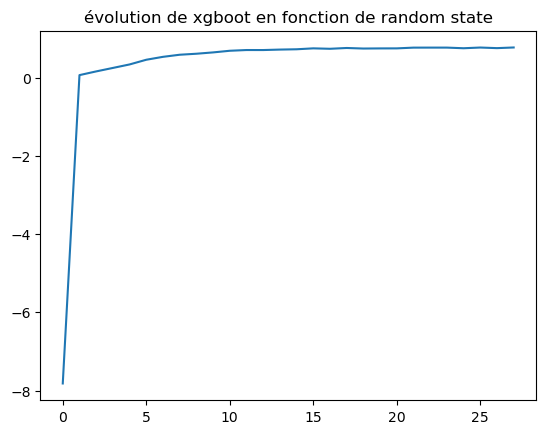

In [52]:
plt.figure()
plt.plot(a)
plt.title("évolution de xgboot en fonction de random state")

In [61]:
sample = pd.DataFrame([{
    'Levy': 836,
    'Manufacturer': 'CHEVROLET',
    'Model': 'Hatchback',
    'Prod. year': 2020,
    'Category': 'RX450',
    'Leather interior': 7,
    'Fuel type': 'Hybrid',
    'Engine volume': 3.0,
    'Mileage': 116,
    'Cylinders': 8,
    'Gear box type': 'Automatic',
    'Airbags': 4
}])
sample = sample.reindex(columns=X_train.columns, fill_value=0)
model.fit(X_train, y_train)
pred = model.predict(sample)

b= model.predict(sample)
print(b)

[75397.20146465]


In [66]:
import joblib 
joblib.dump(model,"model.pkl")
joblib.dump(X_train.columns,"columns.pkl")

['columns.pkl']

In [140]:
df["Airbags"].unique()

array([12.,  8.,  2.,  0.,  4.,  6., 10.,  3.,  1., 16.,  5.,  7.,  9.,
       11., 14., 15., 13.])